Passo 1. Baixe os dados do classroom na sua máquina.

Passo 2. Carregue o conjunto de dados da sua máquina para o Colab.

Passo 3. Siga os passos abaixo.

In [ ]:
# 1. Importar nossas bibliotecas
import pandas as pd # Biblioteca para trabalhar com os datasets
import numpy as np # Biblioteca para trabalharmos com arrays
import matplotlib.pyplot as plt  # Biblioteca para fazer os gráficos
from sklearn.cluster import KMeans # KMeans, algoritmo que separa os dados em clusters
from sklearn.metrics import silhouette_score # Score que apresenta a melhor separação dos dados
from yellowbrick.cluster import KElbowVisualizer # Fazer a visualização
from sklearn.decomposition import PCA # Analise componentes principais (Reduz dimensionalidade dos dados, pode trasformar várias variáveis em apenas duas mantendo a variância dos dados)

In [ ]:
# Le o conjunto de dados, passando o parametro de separação por tabulação (\t)
df = pd.read_csv('/content/marketing_campaign.csv', sep='\t')

In [ ]:
df.sample(4)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
1546,6365,1987,2n Cycle,Married,30390.0,0,0,02-09-2013,5,10,...,6,0,0,0,0,0,0,3,11,0
1023,4550,1966,Master,Together,33564.0,0,1,24-06-2014,51,61,...,5,0,0,0,0,0,0,3,11,0
943,5386,1953,Graduation,Together,94384.0,0,0,04-03-2013,62,1111,...,2,0,1,1,1,0,0,3,11,1
2067,7899,1952,PhD,Married,77610.0,0,1,29-10-2012,70,1245,...,7,0,0,0,0,0,0,3,11,0


In [ ]:
simulacao1 = df[['MntWines', 'Recency']] ### Muda as variáveis
s1 = simulacao1.values

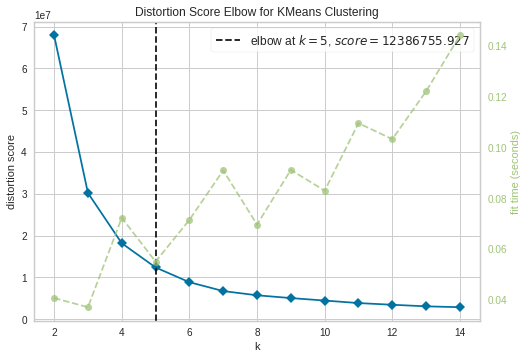

In [ ]:
model = KMeans() # Instancia o modelo do kmeans
visualizer = KElbowVisualizer(model, k=(2, 15), timings=True) # gera o modelo de visualização com teste de 2 a 15 clusters usando Elbow Method
visualizer.fit(s1) # treinamos o modelo
visualizer.show() # visualizamos o modelo

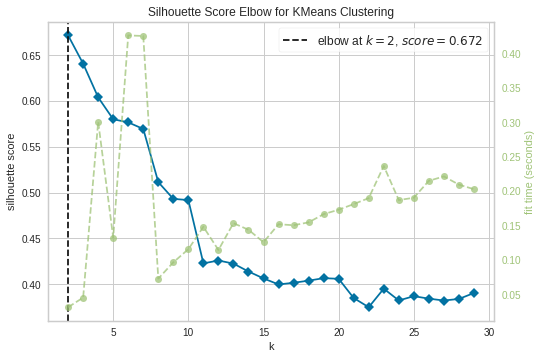

In [ ]:
model = KMeans() # Instancia o modelo do kmeans
visualizer = KElbowVisualizer(model, k=(2, 30), metric='silhouette', timings=True) # gera o modelo de visualização com teste de 2 a 15 clusters usando avaliação de Silhouette
visualizer.fit(s1) # treinamos o modelo
visualizer.show() # visualizamos o modelo

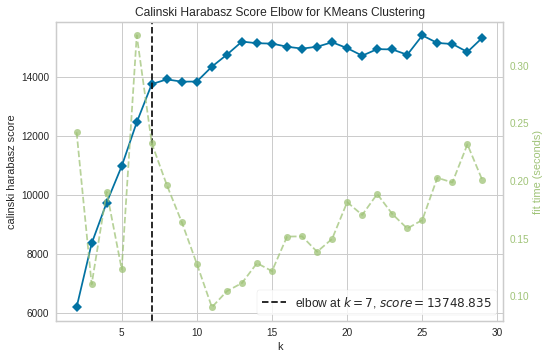

In [ ]:
model = KMeans() # Instancia o modelo do kmeans
visualizer = KElbowVisualizer(model, k=(2, 30), metric='calinski_harabasz', timings=True) # gera o modelo de visualização com teste de 2 a 15 clusters usando avaliação de calinski
visualizer.fit(s1) # treinamos o modelo
visualizer.show() # visualizamos o modelo

In [ ]:
kmeans_final = KMeans(n_clusters=5) # Criamos o modelo com 5 clusters e treinamos
kmeans_final.fit(s1)

KMeans(n_clusters=5)

In [ ]:
cluster_pred = kmeans_final.predict(s1)

In [ ]:
cluster_centers = kmeans_final.cluster_centers_

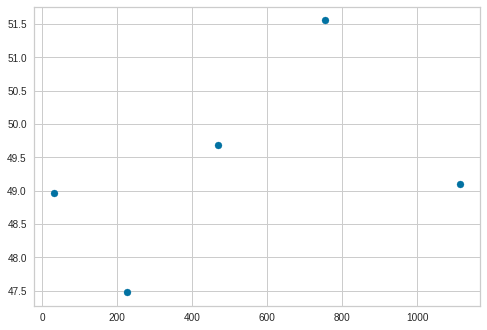

In [ ]:
plt.scatter(cluster_centers[:,0], cluster_centers[:,1])
plt.show()

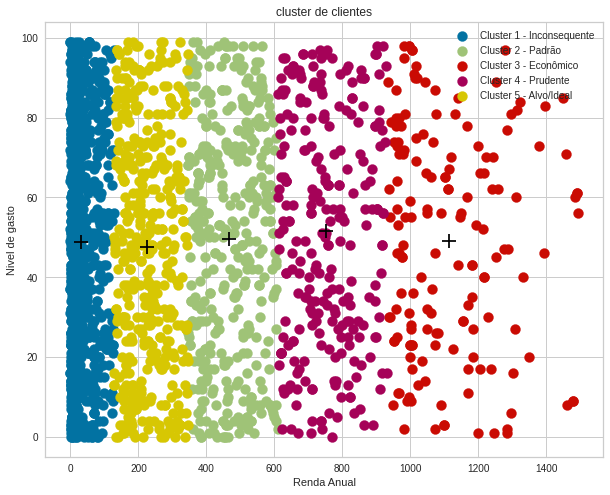

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(s1[cluster_pred==0, 0], s1[cluster_pred==0, 1],s=100, label='Cluster 1 - Inconsequente')
plt.scatter(s1[cluster_pred==1, 0], s1[cluster_pred==1, 1],s=100, label='Cluster 2 - Padrão')
plt.scatter(s1[cluster_pred==2, 0], s1[cluster_pred==2, 1],s=100, label='Cluster 3 - Econômico')
plt.scatter(s1[cluster_pred==3, 0], s1[cluster_pred==3, 1],s=100, label='Cluster 4 - Prudente')
plt.scatter(s1[cluster_pred==4, 0], s1[cluster_pred==4, 1],s=100, label='Cluster 5 - Alvo/Ideal')
plt.scatter(cluster_centers[:,0],cluster_centers[:,1], marker='+', s=200, c='black')
plt.legend()
plt.title('cluster de clientes')
plt.xlabel('Renda Anual')
plt.ylabel('Nivel de gasto')
plt.show()

In [ ]:
pca = PCA(n_components=2).fit(s1)
X_pca = pca.transform(s1)

print('Variância explicada pela dimensão 1: %0.3f' % (pca.explained_variance_ratio_[0:1].sum() *100))
print('Variância explicada pela dimensão 2: %0.3f' % (((pca.explained_variance_ratio_[0:2].sum()) - (pca.explained_variance_ratio_[0:1].sum() )) *100))
print('Variância explicada pelas duas dimensões: %0.3f' % (pca.explained_variance_ratio_[0:2].sum() *100))

Variância explicada pela dimensão 1: 99.265
Variância explicada pela dimensão 2: 0.735
Variância explicada pelas duas dimensões: 100.000
